In [16]:
'''
ÖLÜM VERİLERİ
total_deaths / new_deaths / new_deaths_smoothed	Aynı mantık, ölüm için
*_per_million uzantılı olanlar	Yukarıdakilerin milyon kişi başına normalize edilmiş hali — 
ülkeler arası karşılaştırma için bunları kullanacağız
'''

'\nÖLÜM VERİLERİ\ntotal_deaths / new_deaths / new_deaths_smoothed\tAynı mantık, ölüm için\n*_per_million uzantılı olanlar\tYukarıdakilerin milyon kişi başına normalize edilmiş hali — \nülkeler arası karşılaştırma için bunları kullanacağız\n'

In [17]:
'''
Aşırı Ölüm (Excess Mortality)
excess_mortality	Beklenen ölüm sayısına göre fazladan ölüm yüzdesi
(COVID'in resmi sayılara yansımayan gerçek etkisini gösterir)
excess_mortality_cumulative	Kümülatif hali
excess_mortality_cumulative_absolute	Mutlak sayı olarak
excess_mortality_cumulative_per_million	Milyon kişi başına 
'''

"\nAşırı Ölüm (Excess Mortality)\nexcess_mortality\tBeklenen ölüm sayısına göre fazladan ölüm yüzdesi\n(COVID'in resmi sayılara yansımayan gerçek etkisini gösterir)\nexcess_mortality_cumulative\tKümülatif hali\nexcess_mortality_cumulative_absolute\tMutlak sayı olarak\nexcess_mortality_cumulative_per_million\tMilyon kişi başına \n"

In [18]:
#kullancağımız kütüphaneleri yüklüyoruz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#weekly_cases.csv dosyasını kullanacağız
df_countries = pd.read_csv(
    r'C:\Users\nazlican\OneDrive\Masaüstü\CoronaVirusProject\data\processed\countries_clean.csv',
    parse_dates=['date']
)

print("Satır-sütun sayısı:", df_countries.shape)
print("Ülke sayısı:", df_countries['location'].nunique())
print("İlk tarih:", df_countries['date'].min())
print("Son tarih:", df_countries['date'].max())

print(
    "Kalan ülke-tarih tekrarı:",
    df_countries.duplicated(
        subset=['location', 'date']
    ).sum()
)

Satır-sütun sayısı: (324819, 67)
Ülke sayısı: 194
İlk tarih: 2020-01-01 00:00:00
Son tarih: 2024-08-14 00:00:00
Kalan ülke-tarih tekrarı: 0


In [19]:
#total_deaths sütunu için toplam kaç dolu kaç boş satır olduğunu tespit ediyoruz
death_coverage = df_countries.groupby('location').agg(
    toplam_satir=('total_deaths', 'size'),
    dolu_olum_kaydi=('total_deaths', 'count')
)

death_coverage['bos_olum_kaydi'] = (
    death_coverage['toplam_satir']
    - death_coverage['dolu_olum_kaydi']
)

print(
    death_coverage
    .sort_values('dolu_olum_kaydi')
    .head(15)
)

                     toplam_satir  dolu_olum_kaydi  bos_olum_kaydi
location                                                          
Afghanistan                  1674             1674               0
Albania                      1674             1674               0
Algeria                      1674             1674               0
Andorra                      1674             1674               0
Angola                       1674             1674               0
Antigua and Barbuda          1674             1674               0
Argentina                    1678             1674               4
Armenia                      1674             1674               0
Australia                    1674             1674               0
Austria                      1674             1674               0
Azerbaijan                   1674             1674               0
Bahamas                      1674             1674               0
Bahrain                      1674             1674            

In [20]:
#hem dolu hem boş olan ölüm kayıtlarına sahip ülkeler
partial_death_missing = death_coverage[
    (death_coverage['dolu_olum_kaydi'] > 0)
    & (death_coverage['bos_olum_kaydi'] > 0)
].copy()

#sadece eksik ölüm kayıtlarını seçiyoruz
missing_death_rows = df_countries.loc[
    df_countries['location'].isin(partial_death_missing.index)
    & df_countries['total_deaths'].isna(),
    ['location', 'date', 'total_deaths']
].copy()

#sadece dolu ölüm kayıtlarını seçiyoruz
valid_death_range = (
    df_countries.loc[
        df_countries['total_deaths'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_olum_tarihi=('date', 'min'),
        son_dolu_olum_tarihi=('date', 'max')
    )
)

missing_death_positions = missing_death_rows.join(
    valid_death_range,
    on='location'
)

missing_death_positions['bosluk_konumu'] = 'arada'

missing_death_positions.loc[
    missing_death_positions['date']
    < missing_death_positions['ilk_dolu_olum_tarihi'],
    'bosluk_konumu'
] = 'başta'

missing_death_positions.loc[
    missing_death_positions['date']
    > missing_death_positions['son_dolu_olum_tarihi'],
    'bosluk_konumu'
] = 'sonda'

death_missing_position_summary = (
    missing_death_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['başta', 'arada', 'sonda'], fill_value=0)
)

print(death_missing_position_summary)

bosluk_konumu  başta  arada  sonda
location                          
Argentina          4      0      0
Czechia            0      0      8
Estonia            0      0      8
India              0      0      8
Italy              0      0      3
Lithuania          0      0     10
Malaysia           0      0     10
Mexico             4      0      0
New Zealand        0      0      7
Thailand           1      0      0


In [21]:
#toplam ölüm kayıtlarının negatif azaldığı yerleri tespit ediyoruz
death_changes = (
    df_countries[
        ['location', 'date', 'total_deaths']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

death_changes['degisim'] = (
    death_changes
    .groupby('location')['total_deaths']
    .diff()
)

death_decreases = death_changes.loc[
    death_changes['degisim'] < 0
].copy()

print("Toplam ölüm sayısının azaldığı kayıt sayısı:", len(death_decreases))
print(death_decreases.to_string(index=False))

Toplam ölüm sayısının azaldığı kayıt sayısı: 9
        location       date  total_deaths  degisim
       Australia 2023-07-23       22694.0    -76.0
          Canada 2022-06-19       41017.0   -331.0
           Chile 2023-04-02       61050.0  -3432.0
           China 2024-01-14      121916.0    -22.0
       Indonesia 2024-02-11      162050.0     -4.0
          Panama 2023-05-07        8620.0     -1.0
Papua New Guinea 2023-08-13         640.0    -30.0
    Sierra Leone 2022-06-12         125.0     -1.0
        Thailand 2020-11-22           0.0    -60.0


In [22]:
#eksi olarak azalan yerlerin neyden dolayı kaynaklandığını tespit etmeye çalışıyoruz
death_decrease_details = death_decreases.merge(
    df_countries[
        ['location', 'date', 'new_deaths']
    ],
    on=['location', 'date'],
    how='left',#soldaki değerleri korumak için 
    validate='one_to_one'
)

print(death_decrease_details.to_string(index=False))

        location       date  total_deaths  degisim  new_deaths
       Australia 2023-07-23       22694.0    -76.0         NaN
          Canada 2022-06-19       41017.0   -331.0         NaN
           Chile 2023-04-02       61050.0  -3432.0         NaN
           China 2024-01-14      121916.0    -22.0         NaN
       Indonesia 2024-02-11      162050.0     -4.0         NaN
          Panama 2023-05-07        8620.0     -1.0         NaN
Papua New Guinea 2023-08-13         640.0    -30.0         NaN
    Sierra Leone 2022-06-12         125.0     -1.0         NaN
        Thailand 2020-11-22           0.0    -60.0         NaN


In [24]:
#new_deaths sütununda toplam ölüm kaydı,boş ölüm kaydı incelenmesi
new_death_coverage = df_countries.groupby('location').agg(
    toplam_satir=('new_deaths', 'size'),
    dolu_yeni_olum_kaydi=('new_deaths', 'count')
)

new_death_coverage['bos_yeni_olum_kaydi'] = (
    new_death_coverage['toplam_satir']
    - new_death_coverage['dolu_yeni_olum_kaydi']
)

print(
    new_death_coverage
    .sort_values('bos_yeni_olum_kaydi', ascending=False)
    .head(15)
)

             toplam_satir  dolu_yeni_olum_kaydi  bos_yeni_olum_kaydi
location                                                            
France               1674                  1274                  400
Germany              1674                  1282                  392
Spain                1674                  1282                  392
Malaysia             1684                  1674                   10
Lithuania            1684                  1674                   10
Estonia              1682                  1674                    8
India                1682                  1674                    8
Czechia              1682                  1674                    8
New Zealand          1681                  1674                    7
Argentina            1678                  1674                    4
Mexico               1678                  1674                    4
Italy                1677                  1674                    3
Thailand             1675         

In [ ]:
#total_deaths de olduğu gibi  yeni ölüm kayıtlarında eksik ölümler veri setinin başında mı ortasında mı sonunda mı tespit ediyoruz
partial_new_death_missing = new_death_coverage[
    (new_death_coverage['dolu_yeni_olum_kaydi'] > 0)
    & (new_death_coverage['bos_yeni_olum_kaydi'] > 0)
].copy()

missing_new_death_rows = df_countries.loc[
    df_countries['location'].isin(
        partial_new_death_missing.index
    )
    & df_countries['new_deaths'].isna(),
    ['location', 'date', 'new_deaths']
].copy()

valid_new_death_range = (
    df_countries.loc[
        df_countries['new_deaths'].notna()
    ]
    .groupby('location')
    .agg(
        ilk_dolu_yeni_olum_tarihi=('date', 'min'),
        son_dolu_yeni_olum_tarihi=('date', 'max')
    )
)

missing_new_death_positions = missing_new_death_rows.join(
    valid_new_death_range,
    on='location'
)

missing_new_death_positions['bosluk_konumu'] = 'arada'

missing_new_death_positions.loc[
    missing_new_death_positions['date']
    < missing_new_death_positions[
        'ilk_dolu_yeni_olum_tarihi'
    ],
    'bosluk_konumu'
] = 'başta'

missing_new_death_positions.loc[
    missing_new_death_positions['date']
    > missing_new_death_positions[
        'son_dolu_yeni_olum_tarihi'
    ],
    'bosluk_konumu'
] = 'sonda'

new_death_missing_position_summary = (
    missing_new_death_positions
    .groupby(['location', 'bosluk_konumu'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['başta', 'arada', 'sonda'], fill_value=0)
)

print(new_death_missing_position_summary)

bosluk_konumu     başta  arada  sonda
location                             
Argentina             4      0      0
Australia             0      1      0
Canada                0      1      0
Chile                 0      1      0
China                 0      1      0
Czechia               0      0      8
Estonia               0      0      8
France                0      0    400
Germany               0      0    392
India                 0      0      8
Indonesia             0      1      0
Italy                 0      0      3
Lithuania             0      0     10
Malaysia              0      0     10
Mexico                4      0      0
New Zealand           0      0      7
Panama                0      1      0
Papua New Guinea      0      1      0
Sierra Leone          0      1      0
Spain                 0      0    392
Thailand              1      1      0


In [27]:
#negatif günlük ölüm kayıtlarını kontrol etme,hatalı giriş var mı kontrol ediyoruz
new_death_changes = (
    df_countries[
        ['location', 'date', 'new_deaths']
    ]
    .sort_values(['location', 'date'])
    .copy()
)

negative_new_deaths = new_death_changes.loc[
    new_death_changes['new_deaths'] < 0
].copy()

print(
    "Negatif new_deaths kayıt sayısı:",
    len(negative_new_deaths)
)

print(negative_new_deaths.to_string(index=False))

Negatif new_deaths kayıt sayısı: 0
Empty DataFrame
Columns: [location, date, new_deaths]
Index: []


In [28]:
#günlük ölüm kayıtlarını pazartesi-pazar diye ayırıyoruz ve ona göre incelemde bulunacağız
daily_deaths = df_countries[
    ['location', 'date', 'new_deaths']
].copy()

daily_deaths['hafta_baslangici'] = (
    daily_deaths['date']
    - pd.to_timedelta(
        daily_deaths['date'].dt.dayofweek,
        unit='D'
    )
)

weekly_deaths = (
    daily_deaths
    .groupby(['location', 'hafta_baslangici'])
    .agg(
        mevcut_olum_toplami=(
            'new_deaths',
            lambda values: values.sum(min_count=1)
        ),
        kayitli_gun=('date', 'nunique'),
        dolu_gun=('new_deaths', 'count')
    )
    .reset_index()
)

weekly_deaths['eksik_gun'] = (
    7 - weekly_deaths['dolu_gun']
)

weekly_deaths['tam_hafta'] = (
    weekly_deaths['dolu_gun'] == 7
)

print(weekly_deaths.head(10).to_string(index=False))

   location hafta_baslangici  mevcut_olum_toplami  kayitli_gun  dolu_gun  eksik_gun  tam_hafta
Afghanistan       2019-12-30                  0.0            1         1          6      False
Afghanistan       2020-01-06                  0.0            7         7          0       True
Afghanistan       2020-01-13                  0.0            7         7          0       True
Afghanistan       2020-01-20                  0.0            7         7          0       True
Afghanistan       2020-01-27                  0.0            7         7          0       True
Afghanistan       2020-02-03                  0.0            7         7          0       True
Afghanistan       2020-02-10                  0.0            7         7          0       True
Afghanistan       2020-02-17                  0.0            7         7          0       True
Afghanistan       2020-02-24                  0.0            7         7          0       True
Afghanistan       2020-03-02                  0.0 

In [30]:
#eksik günü olan haftaları,dolu günü olan haftaları ve hiç dolu günü olmayan haftaları belirliyoruz 
weekly_deaths['veri_durumu'] = (
    weekly_deaths['dolu_gun'].astype(str)
    + '/7 gün dolu — '
    + weekly_deaths['eksik_gun'].astype(str)
    + ' gün eksik'
)

weekly_deaths.loc[
    weekly_deaths['tam_hafta'],
    'veri_durumu'
] = 'Tam hafta — 7/7 gün dolu'

weekly_deaths.loc[
    weekly_deaths['dolu_gun'] == 0,
    'veri_durumu'
] = 'Veri yok — 0/7 gün dolu'

print(
    weekly_deaths[
        [
            'location',
            'hafta_baslangici',
            'mevcut_olum_toplami',
            'dolu_gun',
            'eksik_gun',
            'veri_durumu'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_olum_toplami  dolu_gun  eksik_gun                veri_durumu
Afghanistan       2019-12-30                  0.0         1          6 1/7 gün dolu — 6 gün eksik
Afghanistan       2020-01-06                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-13                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-20                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-01-27                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-03                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-10                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-17                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       2020-02-24                  0.0         7          0   Tam hafta — 7/7 gün dolu
Afghanistan       20

In [31]:
weekly_deaths_analysis = (
    weekly_deaths
    .sort_values(['location', 'hafta_baslangici'])
    .copy()
)

weekly_deaths_analysis['onceki_hafta_tarihi'] = (
    weekly_deaths_analysis
    .groupby('location')['hafta_baslangici']
    .shift(1)#önceki hafta bilgilerini getirmek için 
)

weekly_deaths_analysis['onceki_hafta_olum'] = (
    weekly_deaths_analysis
    .groupby('location')['mevcut_olum_toplami']
    .shift(1)
)

weekly_deaths_analysis['onceki_hafta_tam'] = (
    weekly_deaths_analysis
    .groupby('location')['tam_hafta']
    .shift(1)
    .eq(True)
)

weekly_deaths_analysis['hafta_araligi'] = (
    weekly_deaths_analysis['hafta_baslangici']
    - weekly_deaths_analysis['onceki_hafta_tarihi']
).dt.days

weekly_deaths_analysis['haftalik_olum_degisim'] = (
    weekly_deaths_analysis['mevcut_olum_toplami']
    - weekly_deaths_analysis['onceki_hafta_olum']
).where(
    weekly_deaths_analysis['tam_hafta']
    & weekly_deaths_analysis['onceki_hafta_tam']
    & weekly_deaths_analysis['hafta_araligi'].eq(7)
)

valid_death_percentage = (
    weekly_deaths_analysis['onceki_hafta_olum'].gt(0)
    & weekly_deaths_analysis['haftalik_olum_degisim'].notna()
)

weekly_deaths_analysis['haftalik_olum_degisim_yuzde'] = (
    weekly_deaths_analysis['haftalik_olum_degisim']
    .div(weekly_deaths_analysis['onceki_hafta_olum'])
    .mul(100)
    .where(valid_death_percentage)
)

print(
    weekly_deaths_analysis[
        [
            'location',
            'hafta_baslangici',
            'mevcut_olum_toplami',
            'onceki_hafta_olum',
            'tam_hafta',
            'onceki_hafta_tam',
            'haftalik_olum_degisim',
            'haftalik_olum_degisim_yuzde'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_olum_toplami  onceki_hafta_olum  tam_hafta  onceki_hafta_tam  haftalik_olum_degisim  haftalik_olum_degisim_yuzde
Afghanistan       2019-12-30                  0.0                NaN      False             False                    NaN                          NaN
Afghanistan       2020-01-06                  0.0                0.0       True             False                    NaN                          NaN
Afghanistan       2020-01-13                  0.0                0.0       True              True                    0.0                          NaN
Afghanistan       2020-01-20                  0.0                0.0       True              True                    0.0                          NaN
Afghanistan       2020-01-27                  0.0                0.0       True              True                    0.0                          NaN
Afghanistan       2020-02-03                  0.0                0.0       True              True   

In [33]:
#milyon kişi başına analizi yapıyoruz
population_by_location = (
    df_countries
    .groupby('location')['population']
    .first()
)

weekly_deaths_analysis['population'] = (
    weekly_deaths_analysis['location']
    .map(population_by_location)
)

weekly_deaths_analysis['haftalik_olum_milyon_basina'] = (
    weekly_deaths_analysis['mevcut_olum_toplami']
    / weekly_deaths_analysis['population']
    * 1_000_000 #daha adil bir karşılaştırma için
)

print(
    weekly_deaths_analysis[
        [
            'location',
            'hafta_baslangici',
            'mevcut_olum_toplami',
            'population',
            'haftalik_olum_milyon_basina'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_olum_toplami  population  haftalik_olum_milyon_basina
Afghanistan       2019-12-30                  0.0    41128772                     0.000000
Afghanistan       2020-01-06                  0.0    41128772                     0.000000
Afghanistan       2020-01-13                  0.0    41128772                     0.000000
Afghanistan       2020-01-20                  0.0    41128772                     0.000000
Afghanistan       2020-01-27                  0.0    41128772                     0.000000
Afghanistan       2020-02-03                  0.0    41128772                     0.000000
Afghanistan       2020-02-10                  0.0    41128772                     0.000000
Afghanistan       2020-02-17                  0.0    41128772                     0.000000
Afghanistan       2020-02-24                  0.0    41128772                     0.000000
Afghanistan       2020-03-02                  0.0    41128772                     0.000000

In [35]:
#pazar gününe kadar toplam ölüm kayıtlarını ele alacağız
week_end_deaths = df_countries.loc[
    df_countries['date'].dt.dayofweek == 6,
    ['location', 'date', 'total_deaths']
].copy()

week_end_deaths = week_end_deaths.rename(
    columns={
        'date': 'hafta_sonu',
        'total_deaths': 'hafta_sonu_toplam_olum'
    }
)

weekly_deaths_final = weekly_deaths_analysis.copy()

weekly_deaths_final['hafta_sonu'] = (
    weekly_deaths_final['hafta_baslangici']
    + pd.Timedelta(days=6)
)

weekly_deaths_final = weekly_deaths_final.merge(
    week_end_deaths,
    on=['location', 'hafta_sonu'],
    how='left',
    validate='one_to_one'
)

weekly_deaths_final['hafta_sonu_toplam_olum_eksik'] = (
    weekly_deaths_final['hafta_sonu_toplam_olum'].isna()
)

print(
    weekly_deaths_final[
        [
            'location',
            'hafta_baslangici',
            'hafta_sonu',
            'mevcut_olum_toplami',
            'veri_durumu',
            'hafta_sonu_toplam_olum',
            'hafta_sonu_toplam_olum_eksik'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici hafta_sonu  mevcut_olum_toplami                veri_durumu  hafta_sonu_toplam_olum  hafta_sonu_toplam_olum_eksik
Afghanistan       2019-12-30 2020-01-05                  0.0 1/7 gün dolu — 6 gün eksik                     0.0                         False
Afghanistan       2020-01-06 2020-01-12                  0.0   Tam hafta — 7/7 gün dolu                     0.0                         False
Afghanistan       2020-01-13 2020-01-19                  0.0   Tam hafta — 7/7 gün dolu                     0.0                         False
Afghanistan       2020-01-20 2020-01-26                  0.0   Tam hafta — 7/7 gün dolu                     0.0                         False
Afghanistan       2020-01-27 2020-02-02                  0.0   Tam hafta — 7/7 gün dolu                     0.0                         False
Afghanistan       2020-02-03 2020-02-09                  0.0   Tam hafta — 7/7 gün dolu                     0.0                         False
Afghan

C:\Users\nazlican\AppData\Local\Temp\ipykernel_30884\1686265322.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  + pd.Timedelta(days=6)


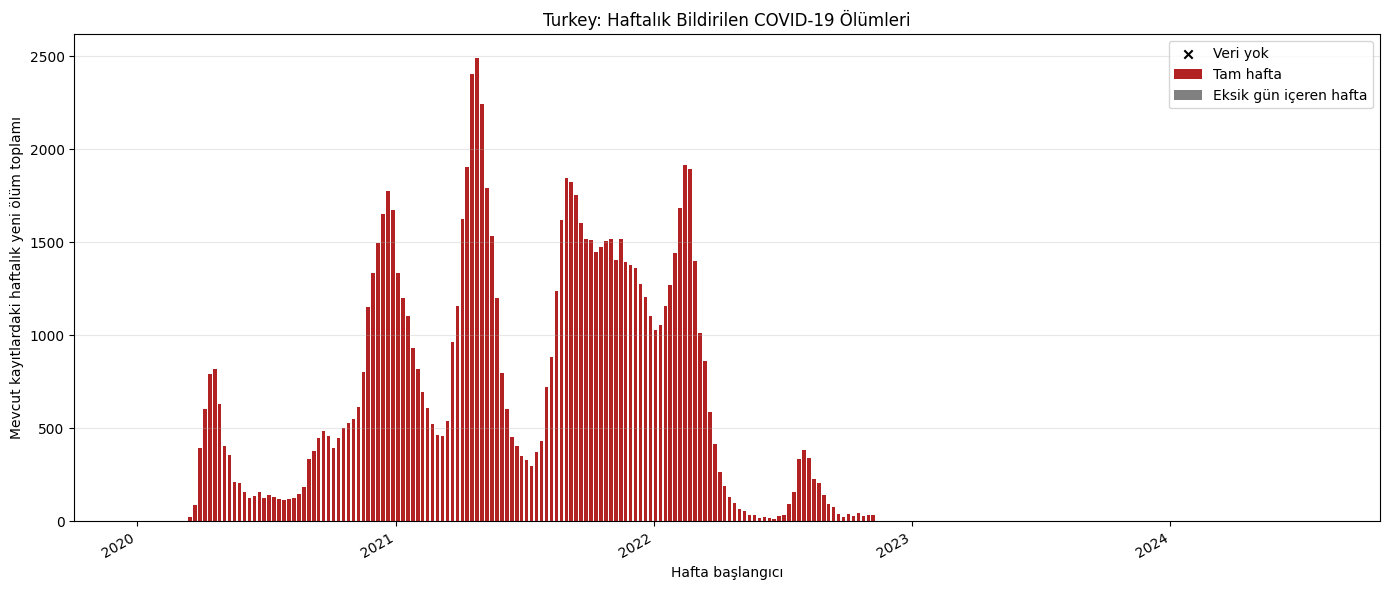

In [36]:
#Türkiye için haftalık ölüm eğilimi nasıl değişmiş
selected_country = 'Turkey'

country_weekly_deaths = (
    weekly_deaths_final.loc[
        weekly_deaths_final['location'] == selected_country
    ]
    .sort_values('hafta_baslangici')
    .copy()
)

full_weeks = country_weekly_deaths[
    country_weekly_deaths['tam_hafta']
]

partial_weeks = country_weekly_deaths[
    (~country_weekly_deaths['tam_hafta'])
    & (country_weekly_deaths['dolu_gun'] > 0)
]

no_data_weeks = country_weekly_deaths[
    country_weekly_deaths['dolu_gun'] == 0
]

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    full_weeks['hafta_baslangici'],
    full_weeks['mevcut_olum_toplami'],
    width=5,
    color='firebrick',
    label='Tam hafta'
)

ax.bar(
    partial_weeks['hafta_baslangici'],
    partial_weeks['mevcut_olum_toplami'],
    width=5,
    color='gray',
    label='Eksik gün içeren hafta'
)

ax.scatter(
    no_data_weeks['hafta_baslangici'],
    [0] * len(no_data_weeks),
    marker='x',
    color='black',
    label='Veri yok',
    zorder=3
)

ax.set_title(
    f'{selected_country}: Haftalık Bildirilen COVID-19 Ölümleri'
)
ax.set_xlabel('Hafta başlangıcı')
ax.set_ylabel('Mevcut kayıtlardaki haftalık yeni ölüm toplamı')
ax.grid(axis='y', alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

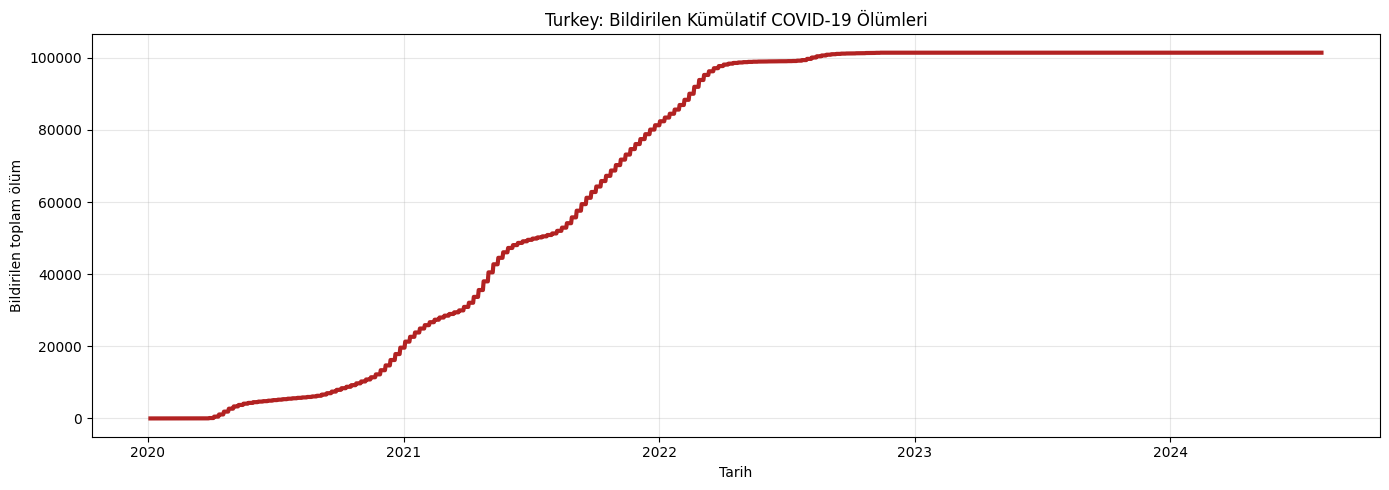

In [40]:
#total_deaths satırını kullanarak toplam ölüm eğrisi nasıl değişmiş inceliyoruz
country_total_deaths = (
    df_countries.loc[
        df_countries['location'] == selected_country,
        ['date', 'total_deaths']
    ]
    .sort_values('date')
    .copy()
)

plt.figure(figsize=(14, 5))

plt.plot(
    country_total_deaths['date'],
    country_total_deaths['total_deaths'],
    color='firebrick',
    linewidth=3
)

plt.title(
    f'{selected_country}: Bildirilen Kümülatif COVID-19 Ölümleri'
)
plt.xlabel('Tarih')
plt.ylabel('Bildirilen toplam ölüm')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
#ortak tarih için toplam ölüm nasıl değişmiş inceliyoruz
#bunun için seçtiğimiz ülkede toplam ölüm kayıtları var mı bakıyoruz
death_comparison_date = pd.Timestamp('2024-08-04')

death_comparison = df_countries.loc[
    df_countries['date'] == death_comparison_date,
    [
        'location',
        'total_deaths',
        'total_deaths_per_million'
    ]
].copy()

print(
    "Seçilen tarihteki ülke sayısı:",
    len(death_comparison)
)

print(
    "Eksik kayıt sayıları:",
    death_comparison[
        ['total_deaths', 'total_deaths_per_million']
    ].isna().sum(),
    sep='\n'
)

death_comparison_valid = death_comparison.dropna(
    subset=[
        'total_deaths',
        'total_deaths_per_million'
    ]
).copy()

print(
    "İki gösterge için de verisi bulunan ülke sayısı:",
    len(death_comparison_valid)
)

Seçilen tarihteki ülke sayısı: 194
Eksik kayıt sayıları:
total_deaths                0
total_deaths_per_million    0
dtype: int64
İki gösterge için de verisi bulunan ülke sayısı: 194


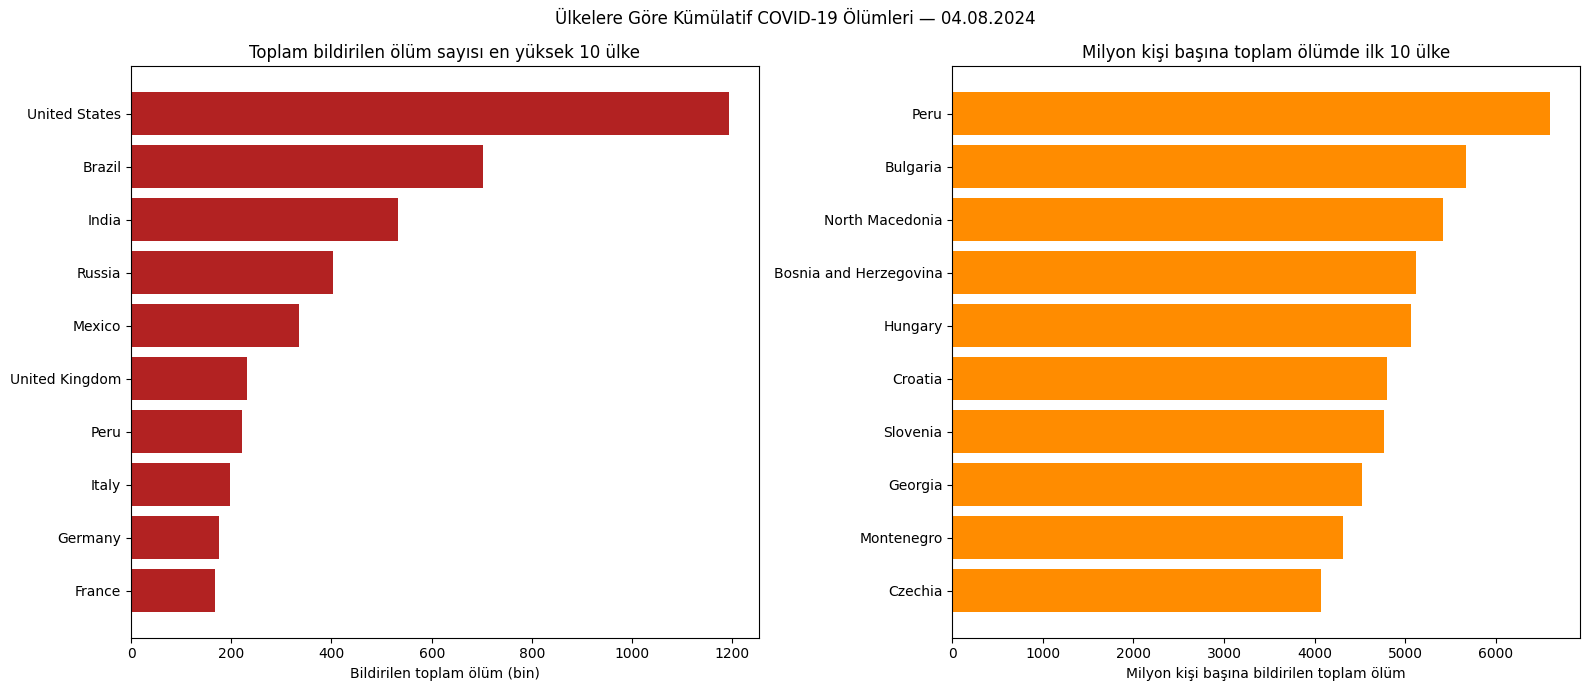

In [45]:
#toplam ölüm bildirilen ölüm sayısı 
#Nüfusa göre milyon kişi başına bildirilen toplam ölüm
top_total_deaths = (
    death_comparison_valid
    .nlargest(10, 'total_deaths')
    .sort_values('total_deaths')
)

top_deaths_per_million = (
    death_comparison_valid
    .nlargest(10, 'total_deaths_per_million')
    .sort_values('total_deaths_per_million')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(
    top_total_deaths['location'],
    top_total_deaths['total_deaths'] / 1_000,
    color='firebrick'
)

axes[0].set_title('Toplam bildirilen ölüm sayısı en yüksek 10 ülke')
axes[0].set_xlabel('Bildirilen toplam ölüm (bin)')

axes[1].barh(
    top_deaths_per_million['location'],
    top_deaths_per_million['total_deaths_per_million'],
    color='darkorange'
)

axes[1].set_title('Milyon kişi başına toplam ölümde ilk 10 ülke')
axes[1].set_xlabel('Milyon kişi başına bildirilen toplam ölüm')

fig.suptitle(
    f'Ülkelere Göre Kümülatif COVID-19 Ölümleri — '
    f'{death_comparison_date:%d.%m.%Y}'
)

plt.tight_layout()
plt.show()

In [51]:
#kaç ülkenin 7 günlük new_deaths verisi tam
weekly_death_country_coverage = (
    weekly_deaths_final[
        weekly_deaths_final['tam_hafta']
    ]
    .groupby('hafta_baslangici')['location']
    .nunique()
    .reset_index(name='ulke_sayisi')
    .sort_values(
        ['ulke_sayisi', 'hafta_baslangici'],
        ascending=[False, False]
    )
)

print(
    weekly_death_country_coverage
    .head(15)
    .to_string(index=False)
)

hafta_baslangici  ulke_sayisi
      2023-06-19          194
      2023-06-12          194
      2023-06-05          194
      2023-05-29          194
      2023-05-22          194
      2023-05-15          194
      2023-05-08          194
      2023-04-24          194
      2023-04-17          194
      2023-04-10          194
      2023-04-03          194
      2023-03-20          194
      2023-03-13          194
      2023-03-06          194
      2023-02-27          194


In [53]:
#en baştaki ülkeyi alıp milyn kişi başına yeni ölüm nasıl değişmiş inceliyoruz
selected_death_week = (
    weekly_death_country_coverage
    .iloc[0]['hafta_baslangici']
)

week_death_comparison = weekly_deaths_final.loc[
    (
        weekly_deaths_final['hafta_baslangici']
        == selected_death_week
    )
    & weekly_deaths_final['tam_hafta'],
    [
        'location',
        'mevcut_olum_toplami',
        'haftalik_olum_milyon_basina'
    ]
].copy()

print(
    "Seçilen hafta:",
    selected_death_week.strftime('%d.%m.%Y')
)

print(
    "Karşılaştırılan ülke sayısı:",
    len(week_death_comparison)
)

print(
    week_death_comparison
    .sort_values(
        'haftalik_olum_milyon_basina',
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

Seçilen hafta: 19.06.2023
Karşılaştırılan ülke sayısı: 194
     location  mevcut_olum_toplami  haftalik_olum_milyon_basina
    Singapore                 27.0                     4.789763
     Slovenia                 10.0                     4.717330
      Finland                 21.0                     3.790104
       Sweden                 29.0                     2.748985
     Portugal                 26.0                     2.531434
    Australia                 59.0                     2.253852
       Greece                 20.0                     1.925860
     Bulgaria                 12.0                     1.769401
      Jamaica                  5.0                     1.768420
United States                584.0                     1.726330


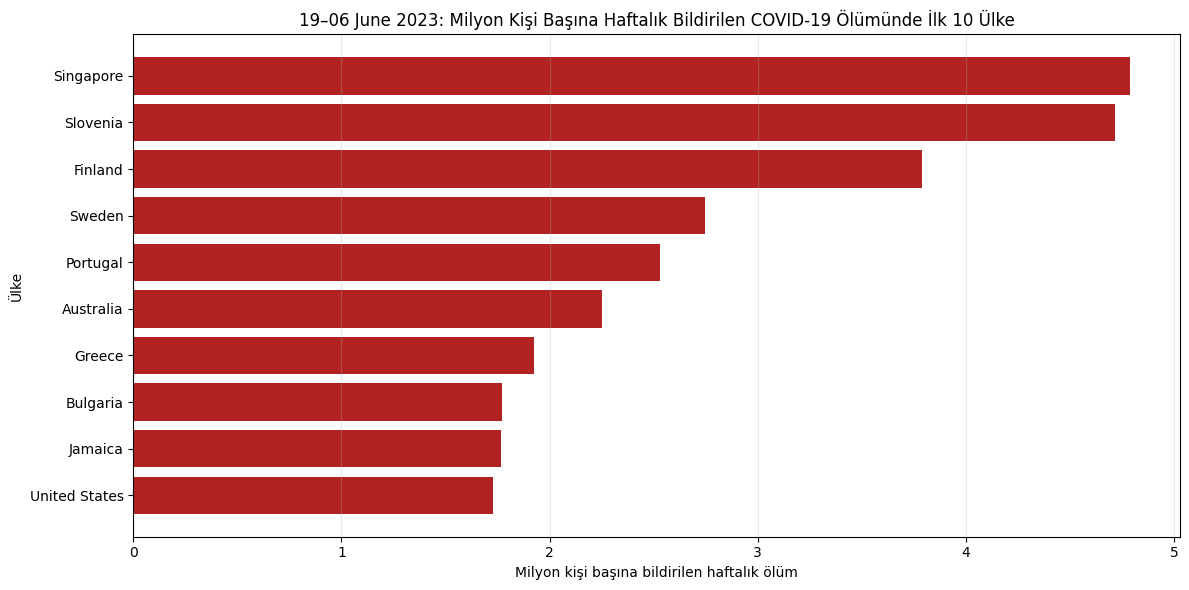

In [54]:
# seçtiğimiz ortak haftada milyon kişi başına haftalık ölüm grafiği
top_weekly_deaths = (
    week_death_comparison
    .nlargest(10, 'haftalik_olum_milyon_basina')
    .sort_values('haftalik_olum_milyon_basina')
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_weekly_deaths['location'],
    top_weekly_deaths['haftalik_olum_milyon_basina'],
    color='firebrick'
)

plt.title(
    f'{selected_death_week:%d–%m %B %Y}: '
    'Milyon Kişi Başına Haftalık Bildirilen COVID-19 Ölümünde İlk 10 Ülke'
)
plt.xlabel('Milyon kişi başına bildirilen haftalık ölüm')
plt.ylabel('Ülke')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
weekly_deaths_final['mevcut_olum_milyon_basina'] = (
    weekly_deaths_final['mevcut_olum_toplami']
    / weekly_deaths_final['population']
    * 1_000_000
)

weekly_deaths_final['haftalik_yeni_olum'] = (
    weekly_deaths_final['mevcut_olum_toplami']
    .where(weekly_deaths_final['tam_hafta'])
)

weekly_deaths_final['haftalik_olum_milyon_basina'] = (
    weekly_deaths_final['haftalik_yeni_olum']
    / weekly_deaths_final['population']
    * 1_000_000
)

print(
    weekly_deaths_final[
        [
            'location',
            'hafta_baslangici',
            'mevcut_olum_toplami',
            'veri_durumu',
            'mevcut_olum_milyon_basina',
            'haftalik_yeni_olum',
            'haftalik_olum_milyon_basina',
            'hafta_sonu_toplam_olum'
        ]
    ].head(15).to_string(index=False)
)

   location hafta_baslangici  mevcut_olum_toplami                veri_durumu  mevcut_olum_milyon_basina  haftalik_yeni_olum  haftalik_olum_milyon_basina  hafta_sonu_toplam_olum
Afghanistan       2019-12-30                  0.0 1/7 gün dolu — 6 gün eksik                   0.000000                 NaN                          NaN                     0.0
Afghanistan       2020-01-06                  0.0   Tam hafta — 7/7 gün dolu                   0.000000                 0.0                     0.000000                     0.0
Afghanistan       2020-01-13                  0.0   Tam hafta — 7/7 gün dolu                   0.000000                 0.0                     0.000000                     0.0
Afghanistan       2020-01-20                  0.0   Tam hafta — 7/7 gün dolu                   0.000000                 0.0                     0.000000                     0.0
Afghanistan       2020-01-27                  0.0   Tam hafta — 7/7 gün dolu                   0.000000            

In [ ]:
#incelediğimiz verileri kaydediyoruz
from pathlib import Path

output_path = Path(
    r'C:\Users\nazlican\OneDrive\Masaüstü\CoronaVirusProject\data\processed\weekly_deaths.csv'
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

weekly_deaths_final.to_csv(
    output_path,
    index=False,
    encoding='utf-8-sig'
)

print("Haftalık ölüm tablosu kaydedildi:", output_path)

Haftalık ölüm tablosu kaydedildi: C:\Users\nazlican\OneDrive\Masaüstü\CoronaVirusProject\data\processed\weekly_deaths.csv


## Ölüm Analizinde Yapılan İşlemler ve Bulgular

- Temizlenmiş ülke verileri kullanıldı. Analizde yalnızca ülkeler yer aldı; ülke-tarih tekrarları temizlenmiş veri dosyasında bulunmamaktadır.

- `total_deaths` sütununun veri kapsamı incelendi. Kısmen eksik kümülatif ölüm kayıtlarındaki boşluklar veri akışının başında veya sonunda bulunmuştur. Dolu ölüm kayıtlarının arasında eksik `total_deaths` kaydı tespit edilmemiştir.

- Kümülatif ölüm sayısındaki azalmalar kontrol edildi. 9 ülke-tarih kaydında `total_deaths` değerinin önceki kayda göre azaldığı görüldü.

- Kümülatif ölümün azaldığı 9 tarihin tamamında `new_deaths` değeri eksikti. Bu birliktelik, eksik günlük ölüm kaydının azalmanın nedeni olduğunu kanıtlamaz. Azalmaların kaynak düzeltmesi veya veri sorunu olup olmadığı doğrulanmadığı için kaynak değerler korundu.

- `new_deaths` sütunundaki eksik kayıtlar başta, arada ve sonda olarak sınıflandırıldı. Australia, Canada, Chile, China, Indonesia, Panama, Papua New Guinea, Sierra Leone ve Thailand için dolu kayıtların arasında birer günlük eksik ölüm kaydı bulundu.

- Negatif `new_deaths` kaydı bulunmadı.

- Günlük yeni ölüm kayıtları pazartesi–pazar dönemlerine göre haftalık olarak gruplandı. Her ülke ve hafta için mevcut ölüm toplamı, dolu gün sayısı ve eksik gün sayısı hesaplandı.

- Tam haftalar, eksik gün içeren haftalar ve hiç veri bulunmayan haftalar `veri_durumu` sütunuyla etiketlendi. Eksik haftalarda yalnızca mevcut günlerin toplamı korundu; bu değer tam haftanın toplamı gibi yorumlanmadı.

- Haftalık ölüm farkı ve yüzde değişimi yalnızca birbirini izleyen iki tam hafta için hesaplandı. Önceki haftanın ölüm toplamı sıfır olduğunda yüzde değişimi boş bırakıldı.

- Haftalık ölüm değerleri milyon kişi başına hesaplandı. Eksik haftalardaki mevcut gün toplamı ile yalnızca tam haftalara ait güvenilir karşılaştırma değeri ayrı sütunlarda tutuldu.

- Her haftanın pazar günündeki `total_deaths` değeri hafta sonu kümülatif ölüm olarak eklendi. Kümülatif ölüm değerleri haftalık olarak toplanmadı.

- Türkiye için haftalık bildirilen ölüm ve kümülatif ölüm eğrileri incelendi. Eksik haftalar grafikte ayrı işaretlenebilecek biçimde hazırlandı.

- 4 Ağustos 2024 tarihinde toplam bildirilen ölüm sayısında ABD, Brezilya ve Hindistan; milyon kişi başına toplam ölümde Peru, Bulgaristan ve Kuzey Makedonya ilk sıralarda yer aldı. Nüfusa göre hesaplama ülke sıralamasını değiştirmektedir.

- Ortak hafta için veri kapsamı incelendi. 19–25 Haziran 2023 haftasında 194 ülkenin tamamında yedi günlük ölüm verisi bulundu. Bu hafta için milyon kişi başına haftalık ölüm karşılaştırması hazırlandı.

- Dashboard için `weekly_deaths.csv` tablosu oluşturuldu. Bu tablo; mevcut ölüm toplamı, veri durumu, haftalık değişim, milyon kişi başına değerler ve hafta sonu kümülatif ölüm bilgisini içerir.

- Fazla ölüm verisi, dashboard planında yer almadığı için bu projenin analiz kapsamına alınmadı.